In [1]:
from random import random, uniform, seed
from matplotlib import pyplot as plt
import numpy as np
import math
import pandas as pd
import os

from calc import distance, intersection, parallel, angle, orthogonal
from line import Line
from plane import Plane
from point import Point
from solver import solve
from vector import Vector

from IPython.display import clear_output

In [2]:
from funcs import generate_n_planes, get_distribution_form_r_k
from funcs import Cube, RegularTriangularPrism
from funcs import make_random_plane_into_cube, make_random_plane_into_prism

In [3]:
PATH = r"C:\\Users\\lizaconst\\Desktop\\RandomSections\\"

try:
    os.mkdir(PATH + 'carbid_model_distributions')
except:
    print("paths are already exist")

## Count estimations of probability density and save it

In [4]:
%%time
seed(3407)
arr_cube = generate_n_planes(polyhedron=Cube(), way=make_random_plane_into_cube, n=1000000)
np.savetxt(PATH + "arr_cube_106.txt", np.array(arr_cube))

clear_output()

Wall time: 21min 13s


In [5]:
%%time
seed(3407)
arr_prism = generate_n_planes(polyhedron=RegularTriangularPrism(), way=make_random_plane_into_prism, n=1000000)
np.savetxt(PATH + "arr_prism_106.txt", np.array(arr_prism))

clear_output()

Wall time: 25min 8s


In [6]:
%%time
seed(3407)
arr_right_hexagonal_prism = get_distribution_form_r_k(PATH, r=1, k=np.sqrt(3)/3, n=1000000)
np.savetxt(PATH + "arr_right_hexagonal_prism_106.txt", np.array(arr_right_hexagonal_prism))

clear_output()

Wall time: 1h 9min 2s


In [7]:
%%time
seed(3407)
arr_1 = get_distribution_form_r_k(PATH, r=1, k=0.5, n=100000)
arr_2 = get_distribution_form_r_k(PATH, r=1, k=1., n=100000)
arr_3 = get_distribution_form_r_k(PATH, r=1, k=2., n=100000)

clear_output()

Wall time: 16min 45s


## Uploading files

In [8]:
arr_cube = np.loadtxt(PATH + "arr_cube_106.txt")
arr_prism = np.loadtxt(PATH + "arr_prism_106.txt")
arr_right_hexagonal_prism = np.loadtxt(PATH + "arr_right_hexagonal_prism_106.txt")

In [9]:
%%time
seed(3407)
arr_1 = get_distribution_form_r_k(PATH, r=1, k=0.5, n=100000)
arr_2 = get_distribution_form_r_k(PATH, r=1, k=1., n=100000)
arr_3 = get_distribution_form_r_k(PATH, r=1, k=2., n=100000)

Wall time: 21 ms


## Make graphics

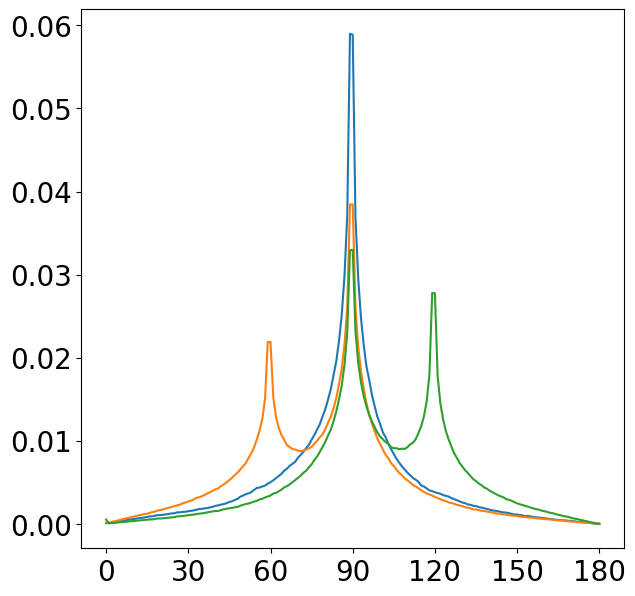

In [10]:
plt.figure(figsize=(7,7))
plt.plot(arr_cube)
plt.plot(arr_prism)
plt.plot(arr_right_hexagonal_prism)
x = np.array([0, 30, 60, 90, 120, 150, 180])
plt.xticks(x, x, size=20)
plt.yticks(size=20)

plt.savefig(PATH + 'cube_prism_hex.pdf')

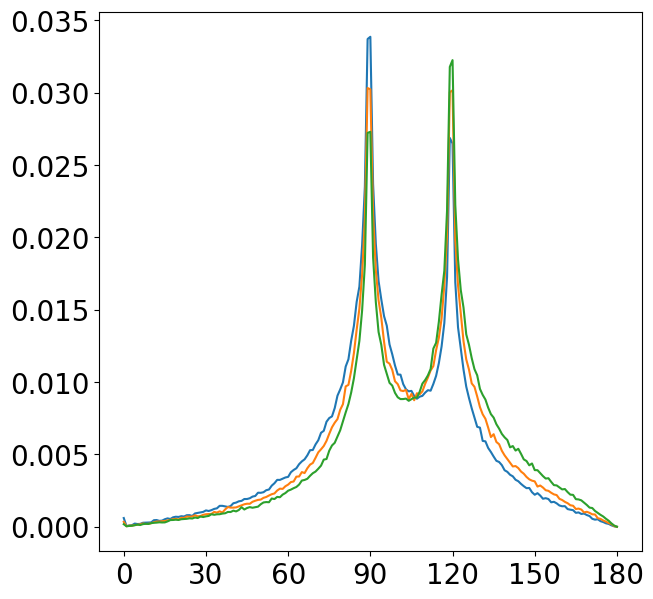

In [11]:
plt.figure(figsize=(7,7))

plt.plot(arr_1, label='r=1, k=0.5')
plt.plot(arr_2, label='r=1, k=1')
plt.plot(arr_3, label='r=1, k=2')

x = np.array([0, 30, 60, 90, 120, 150, 180])
plt.xticks(x, x, size=20)
plt.yticks(size=20)

plt.savefig(PATH + 'trunc-prism-v2.pdf')

## Table of peaks

In [12]:
table1 = pd.DataFrame(np.zeros((2, 3)), columns=['0.5', '1', '2'], index=['90', '120'])

table1['0.5'] = (arr_1[89] + arr_1[90])/2, (arr_1[119] + arr_1[120])/2
table1['1'] = (arr_2[89] + arr_2[90])/2, (arr_2[119] + arr_2[120])/2
table1['2'] = (arr_3[89] + arr_3[90])/2, (arr_3[119] + arr_3[120])/2

In [13]:
table1

,0.5,1,2
90,0.033789,0.030280,0.027261
120,0.026680,0.030102,0.032020
